<a href="https://colab.research.google.com/github/yana-g/graph-analysis/blob/main/03_Community_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3. Community Analysis of the Israeli Actors Collaboration Graph

This notebook detects and analyzes communities in the actor collaboration network for **1990–Today**.

The analysis:

1. Builds the Period C collaboration graph.
2. Compares Louvain and Label Propagation.
3. Selects the partition with the highest modularity.
4. Examines community sizes and central actors.
5. Characterizes the largest communities using genres, recurring directors, and activity periods.
6. Documents the limits of cinematic-style and demographic interpretation.

### 1. Imports

In [1]:
from pathlib import Path
import itertools
import re
import time
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from networkx.algorithms.community import (
    louvain_communities,
    asyn_lpa_communities,
    modularity
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)

### 2. Load and Validate Data

The notebook uses the cleaned `movies_with_actors.csv` file created in Part 1.

In [2]:
DATA_FILE = Path(
    "movies_with_actors.csv"
)

START_YEAR = 1990

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Required input file not found: {DATA_FILE}"
    )

movies_df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8-sig"
)

required_columns = {
    "page_id",
    "movie_title",
    "year",
    "genre",
    "director"
}

missing_columns = (
    required_columns
    - set(movies_df.columns)
)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

movies_df["year"] = pd.to_numeric(
    movies_df["year"],
    errors="coerce"
)

movies_df = (
    movies_df
    .dropna(
        subset=[
            "page_id",
            "movie_title",
            "year"
        ]
    )
    .drop_duplicates(
        subset="page_id"
    )
    .copy()
)

movies_df["year"] = (
    movies_df["year"]
    .astype(int)
)

actor_columns = sorted(
    [
        column
        for column in movies_df.columns
        if re.fullmatch(r"actor_\d+", column)
    ],
    key=lambda column: int(
        column.split("_")[1]
    )
)

if not actor_columns:
    raise ValueError(
        "No actor columns matching actor_1, actor_2, ... were found."
    )

period_c_df = (
    movies_df[
        movies_df["year"].ge(
            START_YEAR
        )
    ]
    .copy()
)

print("All movies:", len(movies_df))
print("Period C movies:", len(period_c_df))
print(
    "Period C year range:",
    period_c_df["year"].min(),
    "-",
    period_c_df["year"].max()
)
print("Actor columns:", actor_columns)

All movies: 1155
Period C movies: 874
Period C year range: 1990 - 2026
Actor columns: ['actor_1', 'actor_2', 'actor_3', 'actor_4', 'actor_5', 'actor_6', 'actor_7', 'actor_8', 'actor_9', 'actor_10']


### 3. Metadata Quality Check

Missing values are reported before community characterization so that the results are interpreted in light of the available coverage.

In [3]:
genre_missing = (
    period_c_df["genre"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

director_missing = (
    period_c_df["director"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

metadata_quality_df = pd.DataFrame({
    "Field": [
        "Genre",
        "Director"
    ],
    "Available": [
        len(period_c_df) - genre_missing,
        len(period_c_df) - director_missing
    ],
    "Missing": [
        genre_missing,
        director_missing
    ]
})

metadata_quality_df["Coverage (%)"] = (
    metadata_quality_df["Available"]
    / len(period_c_df)
    * 100
).round(2)

display(metadata_quality_df)

,Field,Available,Missing,Coverage (%)
0,Genre,736,138,84.21
1,Director,865,9,98.97


### 4. Prepare Data

In [4]:
def clean_text(value):
    """Return a normalized string or an empty string."""
    if pd.isna(value):
        return ""

    return re.sub(
        r"\s+",
        " ",
        str(value)
    ).strip()


def get_movie_actors(row):
    """Return the unique actors listed for one movie."""
    actors = []
    seen = set()

    for column in actor_columns:
        actor = clean_text(
            row[column]
        )

        if not actor:
            continue

        key = actor.casefold()

        if key in seen:
            continue

        seen.add(key)
        actors.append(actor)

    return actors


def split_metadata(value):
    """Split pipe-separated metadata into unique cleaned values."""
    value = clean_text(value)

    if not value:
        return []

    result = []
    seen = set()

    for item in value.split("|"):
        item = clean_text(item)

        if not item:
            continue

        key = item.casefold()

        if key in seen:
            continue

        seen.add(key)
        result.append(item)

    return result

### 5. Build the Period C Graph

Each actor is a node. Two actors are connected when they appeared in the same film. Edge weight is the number of shared films.

In [5]:
def build_actor_graph(movies):
    """Build an undirected weighted actor collaboration graph."""
    graph = nx.Graph()

    for _, row in movies.iterrows():
        actors = get_movie_actors(
            row
        )

        graph.add_nodes_from(
            actors
        )

        for actor_1, actor_2 in itertools.combinations(
            actors,
            2
        ):
            if graph.has_edge(
                actor_1,
                actor_2
            ):
                graph[actor_1][actor_2]["weight"] += 1
                graph[actor_1][actor_2]["movies"].append(
                    row["movie_title"]
                )
                graph[actor_1][actor_2]["years"].append(
                    int(row["year"])
                )
            else:
                graph.add_edge(
                    actor_1,
                    actor_2,
                    weight=1,
                    movies=[row["movie_title"]],
                    years=[int(row["year"])]
                )

    return graph


G_period_c = build_actor_graph(
    period_c_df
)

print("Nodes:", G_period_c.number_of_nodes())
print("Edges:", G_period_c.number_of_edges())
print(
    "Connected components:",
    nx.number_connected_components(
        G_period_c
    )
)
print(
    "Isolated actors:",
    nx.number_of_isolates(
        G_period_c
    )
)

Nodes: 2562
Edges: 19431
Connected components: 62
Isolated actors: 19


### 6. Compare Community-Detection Algorithms

Louvain and Label Propagation are compared using:

- Number of communities
- Number of singleton communities
- Largest and average community size
- Weighted modularity
- Runtime

A higher modularity value indicates a stronger division into internally dense communities.

In [6]:
def run_community_algorithm(
    graph,
    algorithm_name,
    algorithm_function
):
    """Run one community algorithm and summarize its partition."""
    start_time = time.perf_counter()

    communities = [
        set(community)
        for community in algorithm_function(
            graph
        )
    ]

    runtime = (
        time.perf_counter()
        - start_time
    )

    sizes = [
        len(community)
        for community in communities
    ]

    score = modularity(
        graph,
        communities,
        weight="weight"
    )

    return {
        "algorithm": algorithm_name,
        "communities": communities,
        "community_count": len(communities),
        "singleton_communities": sum(
            size == 1
            for size in sizes
        ),
        "largest_community": max(sizes),
        "smallest_community": min(sizes),
        "average_size": float(
            np.mean(sizes)
        ),
        "median_size": float(
            np.median(sizes)
        ),
        "modularity": float(score),
        "runtime_seconds": float(runtime)
    }


algorithm_results = [
    run_community_algorithm(
        G_period_c,
        "Louvain",
        lambda graph: louvain_communities(
            graph,
            weight="weight",
            seed=42
        )
    ),
    run_community_algorithm(
        G_period_c,
        "Label Propagation",
        lambda graph: asyn_lpa_communities(
            graph,
            weight="weight",
            seed=42
        )
    )
]

comparison_df = pd.DataFrame([
    {
        "Algorithm": result["algorithm"],
        "Communities": result["community_count"],
        "Singleton Communities": result["singleton_communities"],
        "Largest Community": result["largest_community"],
        "Smallest Community": result["smallest_community"],
        "Average Size": result["average_size"],
        "Median Size": result["median_size"],
        "Modularity": result["modularity"],
        "Runtime (seconds)": result["runtime_seconds"]
    }
    for result in algorithm_results
])

comparison_df = (
    comparison_df
    .sort_values(
        "Modularity",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    comparison_df.style.format({
        "Average Size": "{:.2f}",
        "Median Size": "{:.2f}",
        "Modularity": "{:.4f}",
        "Runtime (seconds)": "{:.3f}"
    })
)

,Algorithm,Communities,Singleton Communities,Largest Community,Smallest Community,Average Size,Median Size,Modularity,Runtime (seconds)
0,Louvain,83,19,255,1,30.87,4.00,0.4814,0.653
1,Label Propagation,161,19,1763,1,15.91,5.00,0.1927,0.330


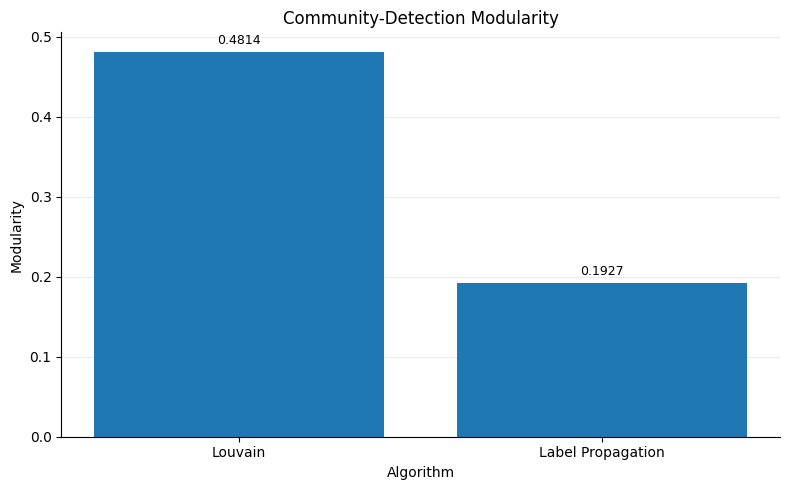

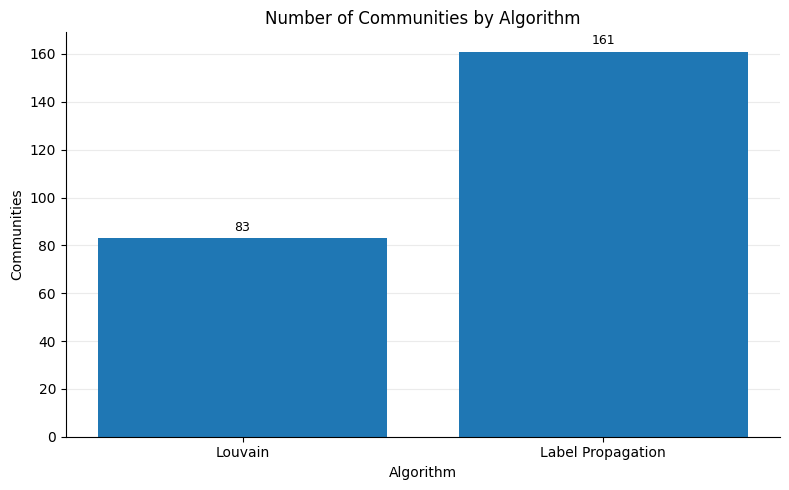

In [7]:
for column, title, ylabel, decimals in [
    (
        "Modularity",
        "Community-Detection Modularity",
        "Modularity",
        4
    ),
    (
        "Communities",
        "Number of Communities by Algorithm",
        "Communities",
        0
    )
]:
    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    plot_data = comparison_df[
        [
            "Algorithm",
            column
        ]
    ]

    bars = ax.bar(
        plot_data["Algorithm"],
        plot_data[column]
    )

    labels = [
        f"{value:.{decimals}f}"
        for value in plot_data[column]
    ]

    ax.bar_label(
        bars,
        labels=labels,
        padding=3,
        fontsize=9
    )

    ax.set_title(title)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

### 7. Select the Best Partition

In [8]:
best_result = max(
    algorithm_results,
    key=lambda result: result["modularity"]
)

best_algorithm = best_result["algorithm"]

communities = sorted(
    best_result["communities"],
    key=len,
    reverse=True
)

print("Selected algorithm:", best_algorithm)
print(
    "Modularity:",
    f"{best_result['modularity']:.4f}"
)
print(
    "Number of communities:",
    len(communities)
)

Selected algorithm: Louvain
Modularity: 0.4814
Number of communities: 83


### 8. Assign Community Labels

In [9]:
actor_to_community = {}

for community_id, community in enumerate(
    communities,
    start=1
):
    for actor in community:
        actor_to_community[actor] = (
            community_id
        )

nx.set_node_attributes(
    G_period_c,
    actor_to_community,
    "community"
)

community_sizes_df = pd.DataFrame({
    "Community": range(
        1,
        len(communities) + 1
    ),
    "Size": [
        len(community)
        for community in communities
    ]
})

community_sizes_df.head(20)

,Community,Size
0,1,255
1,2,236
2,3,174
3,4,163
4,5,146
5,6,137
6,7,132
7,8,117
8,9,110
9,10,104


### 9. Community Sizes

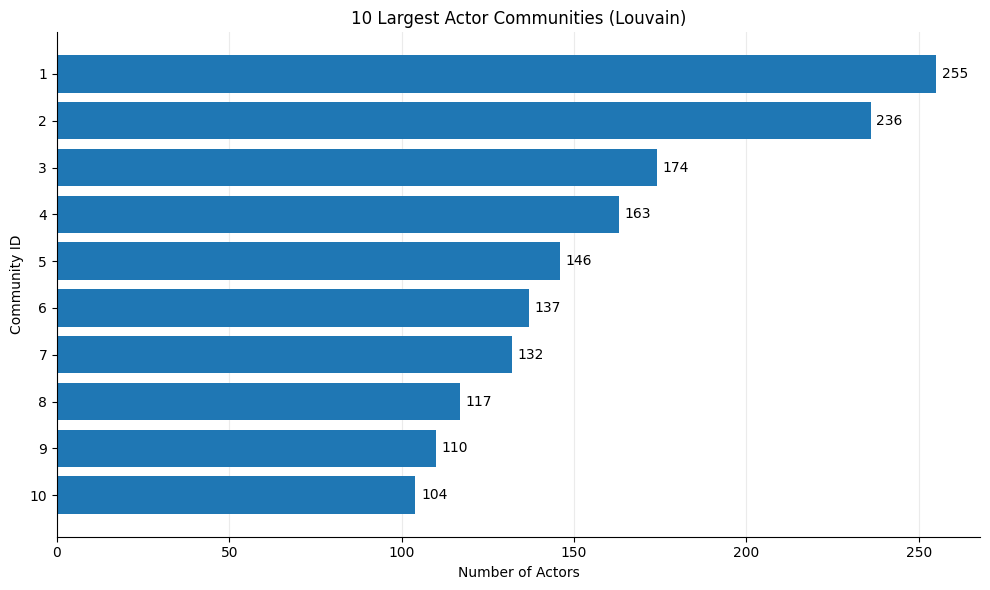

In [10]:
TOP_N_COMMUNITIES = 10

top_sizes = (
    community_sizes_df
    .head(TOP_N_COMMUNITIES)
    .sort_values(
        "Size",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.barh(
    top_sizes["Community"].astype(str),
    top_sizes["Size"]
)

ax.bar_label(
    bars,
    padding=4,
    fontsize=10
)

ax.set_title(
    f"10 Largest Actor Communities ({best_algorithm})"
)
ax.set_xlabel("Number of Actors")
ax.set_ylabel("Community ID")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

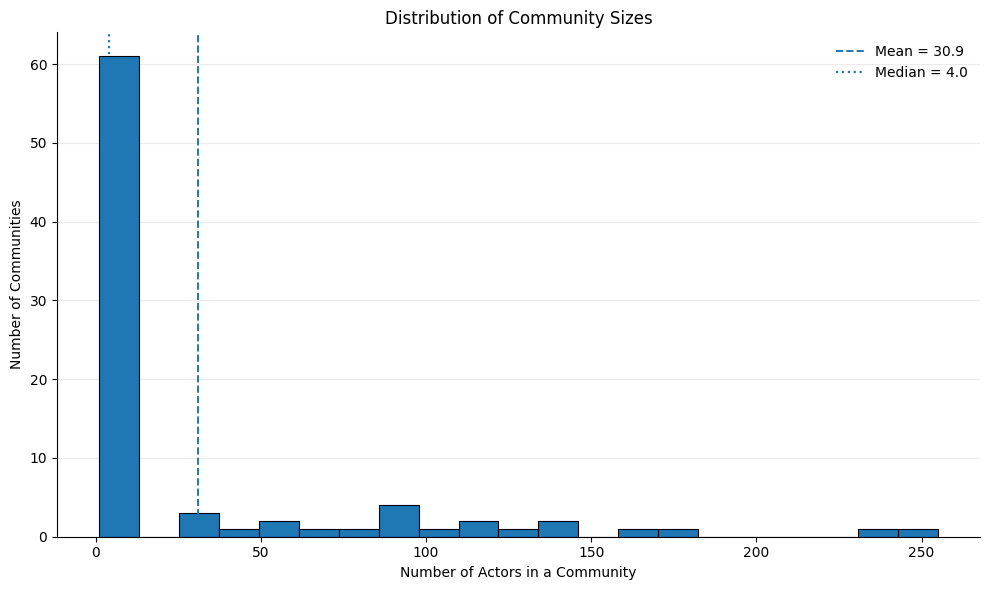

In [11]:
community_sizes = (
    community_sizes_df["Size"]
    .to_numpy()
)

q1, q3 = np.percentile(
    community_sizes,
    [25, 75]
)

iqr = q3 - q1

if iqr > 0:
    bin_width = (
        2
        * iqr
        / np.cbrt(
            len(community_sizes)
        )
    )

    number_of_bins = max(
        5,
        int(np.ceil(
            (
                community_sizes.max()
                - community_sizes.min()
            )
            / bin_width
        ))
    )
else:
    number_of_bins = 10

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    community_sizes,
    bins=number_of_bins,
    edgecolor="black",
    linewidth=0.8
)

ax.axvline(
    community_sizes.mean(),
    linestyle="--",
    linewidth=1.4,
    label=f"Mean = {community_sizes.mean():.1f}"
)

ax.axvline(
    np.median(community_sizes),
    linestyle=":",
    linewidth=1.6,
    label=f"Median = {np.median(community_sizes):.1f}"
)

ax.set_title(
    "Distribution of Community Sizes"
)
ax.set_xlabel(
    "Number of Actors in a Community"
)
ax.set_ylabel(
    "Number of Communities"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### 10. Community Network Visualization

All calculations use the complete graph. For readability, the figure displays the 10 largest communities and up to 25 of the most connected actors from each community.

- Node color represents community membership.
- Node size represents weighted degree in the full network.
- Edge width represents the number of shared films.

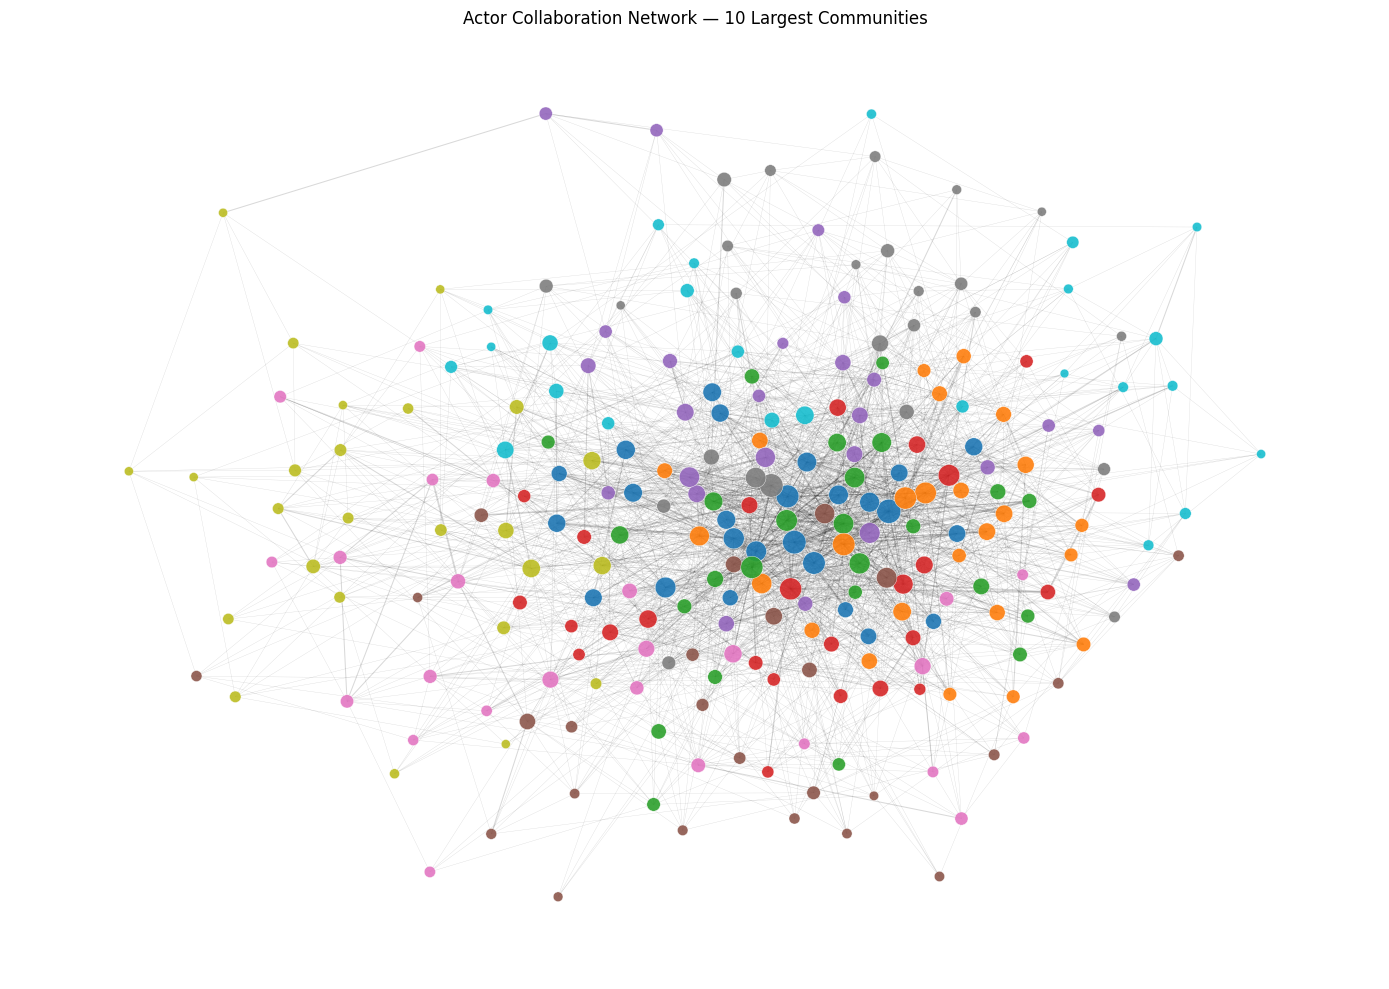

Displayed nodes: 250
Displayed edges: 2491


In [12]:
TOP_COMMUNITIES_FOR_NETWORK = 10
MAX_ACTORS_PER_COMMUNITY = 25
LAYOUT_SEED = 42

largest_community_ids = (
    community_sizes_df
    .head(
        TOP_COMMUNITIES_FOR_NETWORK
    )["Community"]
    .tolist()
)

full_weighted_degree = dict(
    G_period_c.degree(
        weight="weight"
    )
)

selected_nodes = []

for community_id in largest_community_ids:
    community_nodes = [
        actor
        for actor, assigned_id
        in actor_to_community.items()
        if assigned_id == community_id
    ]

    community_nodes = sorted(
        community_nodes,
        key=lambda actor: full_weighted_degree.get(
            actor,
            0
        ),
        reverse=True
    )[:MAX_ACTORS_PER_COMMUNITY]

    selected_nodes.extend(
        community_nodes
    )

network_view = G_period_c.subgraph(
    selected_nodes
).copy()

positions = nx.spring_layout(
    network_view,
    weight="weight",
    seed=LAYOUT_SEED,
    k=0.35,
    iterations=150
)

community_order = {
    community_id: index
    for index, community_id
    in enumerate(
        largest_community_ids
    )
}

node_values = [
    community_order[
        actor_to_community[node]
    ]
    for node in network_view.nodes()
]

node_degrees = np.array([
    full_weighted_degree.get(
        node,
        0
    )
    for node in network_view.nodes()
], dtype=float)

if (
    len(node_degrees) > 0
    and node_degrees.max()
    > node_degrees.min()
):
    node_sizes = (
        40
        + 260
        * (
            (
                np.sqrt(node_degrees)
                - np.sqrt(
                    node_degrees.min()
                )
            )
            / (
                np.sqrt(
                    node_degrees.max()
                )
                - np.sqrt(
                    node_degrees.min()
                )
            )
        )
    )
else:
    node_sizes = np.full(
        len(node_degrees),
        80.0
    )

edge_weights = np.array([
    network_view[u][v].get(
        "weight",
        1
    )
    for u, v
    in network_view.edges()
], dtype=float)

if (
    len(edge_weights) > 0
    and edge_weights.max()
    > edge_weights.min()
):
    edge_widths = (
        0.25
        + 1.5
        * (
            (
                edge_weights
                - edge_weights.min()
            )
            / (
                edge_weights.max()
                - edge_weights.min()
            )
        )
    )
else:
    edge_widths = np.full(
        len(edge_weights),
        0.6
    )

fig, ax = plt.subplots(
    figsize=(14, 10)
)

nx.draw_networkx_edges(
    network_view,
    positions,
    ax=ax,
    width=edge_widths,
    alpha=0.15
)

nx.draw_networkx_nodes(
    network_view,
    positions,
    ax=ax,
    node_color=node_values,
    node_size=node_sizes,
    cmap=plt.cm.tab10,
    linewidths=0.3,
    edgecolors="white",
    alpha=0.9
)

ax.set_title(
    "Actor Collaboration Network — 10 Largest Communities"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()

print(
    "Displayed nodes:",
    network_view.number_of_nodes()
)
print(
    "Displayed edges:",
    network_view.number_of_edges()
)

### 11. Central Actors in the Largest Communities

In [13]:
def get_top_actors_in_community(
    graph,
    community,
    top_n=5
):
    """Rank actors by their internal and global collaboration degrees."""
    subgraph = graph.subgraph(
        community
    )

    internal_degree = dict(
        subgraph.degree()
    )

    weighted_internal_degree = dict(
        subgraph.degree(
            weight="weight"
        )
    )

    rows = []

    for actor in community:
        rows.append({
            "Actor": actor,
            "Internal Degree": internal_degree.get(
                actor,
                0
            ),
            "Weighted Internal Degree": weighted_internal_degree.get(
                actor,
                0
            ),
            "Global Degree": graph.degree(
                actor
            )
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            [
                "Internal Degree",
                "Weighted Internal Degree",
                "Global Degree"
            ],
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


TOP_COMMUNITIES = 10
TOP_ACTORS = 5

central_actor_records = []

for community_id, community in enumerate(
    communities[:TOP_COMMUNITIES],
    start=1
):
    table = get_top_actors_in_community(
        G_period_c,
        community,
        top_n=TOP_ACTORS
    )

    table.insert(
        0,
        "Community",
        community_id
    )

    table.insert(
        1,
        "Community Size",
        len(community)
    )

    central_actor_records.append(
        table
    )

central_actors_df = pd.concat(
    central_actor_records,
    ignore_index=True
)

for community_id in range(
    1,
    TOP_COMMUNITIES + 1
):
    display(
        central_actors_df[
            central_actors_df["Community"]
            .eq(community_id)
        ]
    )

,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
0,1,255,אורי גבריאל,59,69,144
1,1,255,אלברט אילוז,57,71,137
2,1,255,חיים זנאתי,47,51,99
3,1,255,משה איבגי,46,58,170
4,1,255,לבנה פינקלשטיין,45,54,115


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
5,2,236,שרון אלכסנדר,56,62,124
6,2,236,שמיל בן ארי,48,60,136
7,2,236,ארנון צדוק,44,50,79
8,2,236,אסי דיין,43,57,129
9,2,236,יוסף כרמון,41,47,65


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
10,3,174,מוני מושונוב,47,66,111
11,3,174,ולדימיר פרידמן,45,48,117
12,3,174,מנשה נוי,38,52,99
13,3,174,ליאור אשכנזי,37,42,137
14,3,174,אורי קלאוזנר,30,34,106


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
15,4,163,אריה מוסקונה,40,47,93
16,4,163,יגאל עדיקא,39,50,126
17,4,163,זאב רווח,30,34,66
18,4,163,צחי נוי,29,31,73
19,4,163,עמוס לביא,28,31,118


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
20,5,146,יובל שם-טוב,32,33,35
21,5,146,ריימונד אמסלם,29,35,99
22,5,146,אורי הוכמן,28,30,71
23,5,146,לירית בלבן,25,26,51
24,5,146,מרינה שויף,25,26,44


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
25,6,137,אבי קושניר,26,26,38
26,6,137,יבגניה דודינה,24,24,110
27,6,137,מאור שוויצר,21,22,56
28,6,137,דביר בנדק,20,20,104
29,6,137,עופר חיון,19,21,22


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
30,7,132,עלמה זק,35,36,44
31,7,132,אדיר מילר,30,31,39
32,7,132,תובל שפיר,27,31,33
33,7,132,שירן סנדל,19,24,26
34,7,132,ג'וי ריגר,19,19,63


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
35,8,117,צחי גראד,38,44,160
36,8,117,דני שטג,23,26,111
37,8,117,מאיר סוויסה,23,24,44
38,8,117,רמי ברוך,21,21,41
39,8,117,מאור כהן,21,21,41


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
40,9,110,מיכאל אלוני,25,27,78
41,9,110,רוי מילר,25,26,43
42,9,110,אקי אבני,23,23,77
43,9,110,אלון פדות,22,24,30
44,9,110,גיא אדלר,21,24,24


,Community,Community Size,Actor,Internal Degree,Weighted Internal Degree,Global Degree
45,10,104,סלים דאו,32,34,80
46,10,104,ראידה אדון,23,24,39
47,10,104,ח'ליפה נאטור,23,23,41
48,10,104,עודד לאופולד,20,21,56
49,10,104,עוז זהבי,19,22,68


### 12. Assign Movies to Communities

Each movie is assigned to the community containing the largest number of its actors. A cross-community flag records whether the movie contains actors from more than one community.

In [14]:
def movie_community_details(row):
    """Return the primary community and cross-community information."""
    actors = get_movie_actors(
        row
    )

    community_counts = Counter(
        actor_to_community[actor]
        for actor in actors
        if actor in actor_to_community
    )

    if not community_counts:
        return pd.Series({
            "community": np.nan,
            "communities_in_movie": 0,
            "cross_community": False
        })

    maximum_count = max(
        community_counts.values()
    )

    winning_communities = sorted([
        community_id
        for community_id, count
        in community_counts.items()
        if count == maximum_count
    ])

    return pd.Series({
        "community": winning_communities[0],
        "communities_in_movie": len(
            community_counts
        ),
        "cross_community": (
            len(community_counts) > 1
        )
    })


movie_community_data = period_c_df.apply(
    movie_community_details,
    axis=1
)

period_c_df = pd.concat(
    [
        period_c_df,
        movie_community_data
    ],
    axis=1
)

print(
    "Movies assigned to communities:",
    period_c_df["community"]
    .notna()
    .sum()
)

print(
    "Cross-community movies:",
    period_c_df["cross_community"]
    .sum()
)

Movies assigned to communities: 730
Cross-community movies: 507


### 13. Characterize Communities

In [15]:
def most_common_values(
    series,
    top_n=5
):
    """Return the most frequent pipe-separated metadata values."""
    counter = Counter()

    for value in series.dropna():
        counter.update(
            split_metadata(value)
        )

    return counter.most_common(
        top_n
    )


def format_common_values(values):
    """Convert value-frequency pairs into readable text."""
    if not values:
        return "Not available"

    return ", ".join(
        f"{value} ({count})"
        for value, count in values
    )


def activity_period_label(year):
    """Group a movie year into a decade-style activity period."""
    if year <= 1999:
        return "1990–1999"

    if year <= 2009:
        return "2000–2009"

    if year <= 2019:
        return "2010–2019"

    return "2020–Present"


period_c_df["activity_period"] = (
    period_c_df["year"]
    .apply(
        activity_period_label
    )
)

In [16]:
community_summary_rows = []

total_period_movies = len(
    period_c_df
)

for community_id, community in enumerate(
    communities,
    start=1
):
    community_movies = period_c_df[
        period_c_df["community"].eq(
            community_id
        )
    ]

    top_actors = get_top_actors_in_community(
        G_period_c,
        community,
        top_n=5
    )["Actor"].tolist()

    activity_counts = (
        community_movies["activity_period"]
        .value_counts()
    )

    main_activity_period = (
        activity_counts.index[0]
        if not activity_counts.empty
        else "Not available"
    )

    community_summary_rows.append({
        "Community": community_id,
        "Actors": len(community),
        "Movies": len(community_movies),
        "Movie Share (%)": round(
            len(community_movies)
            / total_period_movies
            * 100,
            2
        ),
        "Cross-Community Movies": int(
            community_movies["cross_community"]
            .sum()
        ),
        "Top Actors": ", ".join(
            top_actors
        ),
        "Dominant Genres": format_common_values(
            most_common_values(
                community_movies["genre"],
                top_n=5
            )
        ),
        "Dominant Directors": format_common_values(
            most_common_values(
                community_movies["director"],
                top_n=5
            )
        ),
        "Main Activity Period": main_activity_period,
        "Average Movie Year": (
            round(
                community_movies["year"].mean(),
                1
            )
            if not community_movies.empty
            else np.nan
        ),
        "First Movie Year": (
            int(
                community_movies["year"].min()
            )
            if not community_movies.empty
            else np.nan
        ),
        "Last Movie Year": (
            int(
                community_movies["year"].max()
            )
            if not community_movies.empty
            else np.nan
        )
    })

community_summary_df = (
    pd.DataFrame(
        community_summary_rows
    )
    .sort_values(
        [
            "Actors",
            "Movies"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    community_summary_df
    .head(10)
    .style.set_properties(
        subset=[
            "Top Actors",
            "Dominant Genres",
            "Dominant Directors"
        ],
        **{
            "text-align": "left",
            "white-space": "normal"
        }
    )
)

,Community,Actors,Movies,Movie Share (%),Cross-Community Movies,Top Actors,Dominant Genres,Dominant Directors,Main Activity Period,Average Movie Year,First Movie Year,Last Movie Year
0,1,255,117,13.390000,99,"אורי גבריאל, אלברט אילוז, חיים זנאתי, משה איבגי, לבנה פינקלשטיין","דרמה (67), קומדיה (20), דרמה קומית (6), פשע (3), קומדיה רומנטית (3)","שמי זרחין (5), אריק לובצקי (5), שבי גביזון (4), מתי הררי (4), ארז תדמור (4)",2010–2019,2011.000000,1990,2026
1,2,236,84,9.610000,74,"שרון אלכסנדר, שמיל בן ארי, ארנון צדוק, אסי דיין, יוסף כרמון","דרמה (46), קומדיה (4), עצמאי (3), דרמה קומית (3), להט""בי (2)","אסי דיין (5), ארנון צדוק (5), דורון ערן (4), אורי ברבש (3), מיכל בת-אדם (3)",1990–1999,2004.300000,1990,2024
2,3,174,66,7.550000,55,"מוני מושונוב, ולדימיר פרידמן, מנשה נוי, ליאור אשכנזי, אורי קלאוזנר","דרמה (40), קומדיה (15), רומנטי (4), להט""בי (4), פשע (3)","יבגני רומן (4), צבי שיסל (3), יוסף פיצ'חדזה (3), איתן פוקס (3), ניר ברגמן (3)",2000–2009,2006.800000,1990,2025
3,4,163,48,5.490000,37,"אריה מוסקונה, יגאל עדיקא, זאב רווח, צחי נוי, עמוס לביא","דרמה (19), קומדיה (5), תיעודי (4), דרמה קומית (3), מוזיקלי (2)","יקי יושע (3), חיים בוזגלו (3), זאב רווח (2), אורי ברבש (2), דורון צברי (2)",1990–1999,2004.800000,1990,2025
4,5,146,38,4.350000,29,"יובל שם-טוב, ריימונד אמסלם, אורי הוכמן, לירית בלבן, מרינה שויף","דרמה (17), קומדיה (10), מוזיקלי (7), הרפתקאות (4), קומי (3)","עופר ויצמן (2), ערן ריקליס (2), קובי מחט (2), מנשה נוי (1), אבי כהן (1)",2010–2019,2012.800000,1997,2026
5,6,137,37,4.230000,28,"אבי קושניר, יבגניה דודינה, מאור שוויצר, דביר בנדק, עופר חיון","דרמה (20), קומדיה (7), להט""בי (4), מתח (2), אימה (1)","דני סירקין (2), איתן ענר (2), נוני גפן (2), גבריאל ביבליוביץ (1), אורי ענבר (1)",2010–2019,2012.700000,2002,2024
6,7,132,33,3.780000,23,"עלמה זק, אדיר מילר, תובל שפיר, שירן סנדל, ג'וי ריגר","קומדיה (13), דרמה (9), מוזיקלי (5), לילדים (4), פנטזיה (2)","אבי נשר (5), עופר שפריר (4), ענר פרמינגר (1), אילן הייטנר (1), יורם זקס (1)",2010–2019,2015.400000,1999,2025
7,8,117,29,3.320000,20,"צחי גראד, דני שטג, מאיר סוויסה, רמי ברוך, מאור כהן","דרמה (12), דרמה קומית (2), קומדיה רומנטית (1), מוזיקלי (1), מתח (1)","עודד דוידוף (3), דן וולמן (2), איתן פוקס (1), יקי יושע (1), אורי סיון (1)",2000–2009,2009.800000,1994,2025
8,9,110,20,2.290000,14,"מיכאל אלוני, רוי מילר, אקי אבני, אלון פדות, גיא אדלר","דרמה (13), קומדיה (5), להט""בי (2), אימה (2), אקשן (2)","קובי מחט (3), מיכאל מאיר (2), רוני ניניו (1), דובר קוסשווילי (1), דינה צבי-ריקליס (1)",2010–2019,2016.200000,1995,2026
9,10,104,26,2.970000,15,"סלים דאו, ראידה אדון, ח'ליפה נאטור, עודד לאופולד, עוז זהבי","דרמה (20), להט""בי (2), קומדיה (2), רומנטי (1), פעולה (1)","ערן ריקליס (2), עמוס גיתאי (2), דני ורטה (1), עלי נאסר (1), לינה (1)",2010–2019,2011.200000,1991,2021


### 14. Activity Periods of the Largest Communities

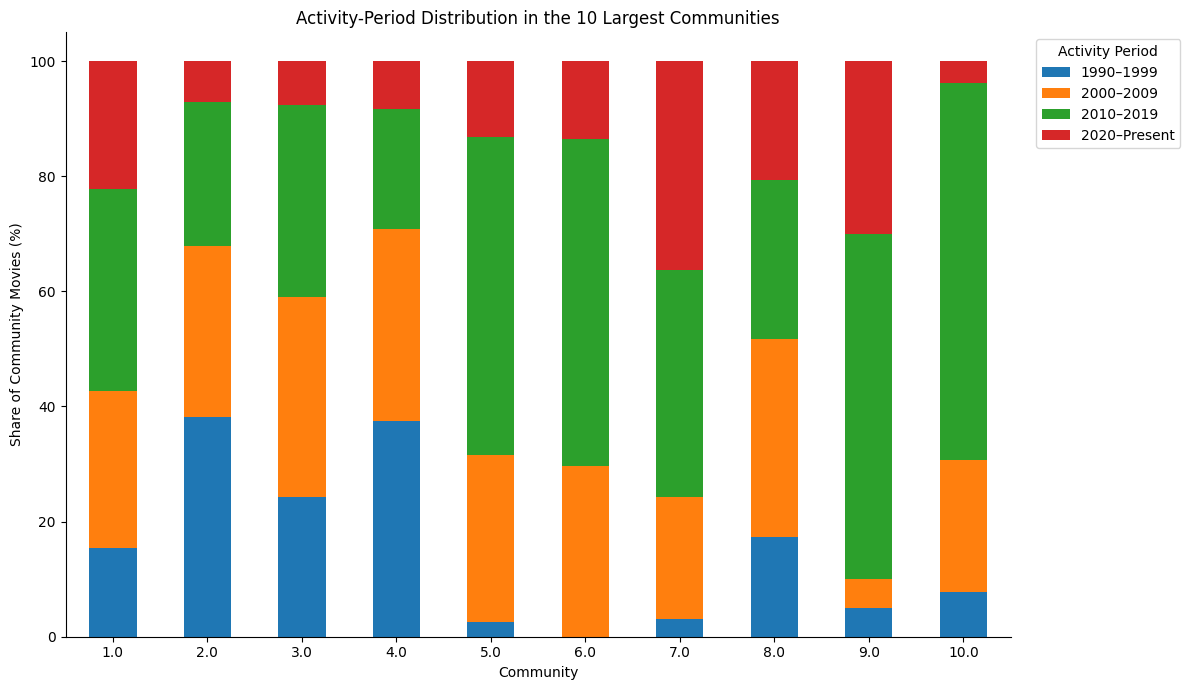

In [17]:
largest_ids = (
    community_summary_df
    .head(10)["Community"]
    .tolist()
)

activity_distribution = (
    period_c_df[
        period_c_df["community"].isin(
            largest_ids
        )
    ]
    .groupby(
        [
            "community",
            "activity_period"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

activity_share = (
    activity_distribution
    .div(
        activity_distribution.sum(
            axis=1
        ),
        axis=0
    )
    * 100
)

ax = activity_share.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

ax.set_title(
    "Activity-Period Distribution in the 10 Largest Communities"
)
ax.set_xlabel("Community")
ax.set_ylabel("Share of Community Movies (%)")
ax.tick_params(
    axis="x",
    rotation=0
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(
    title="Activity Period",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### 15. Cinematic Style Indicators

The dataset does not contain a direct cinematic-style field. Therefore, dominant genres and recurring directors are treated as indicators of cinematic tendencies rather than definitive style labels.

### 16. Demographic Characteristics

The collected dataset does not contain actor-level age, gender, birthplace, ethnicity, or background. A reliable demographic comparison cannot be performed without additional actor-level data. This is reported as a data limitation rather than inferred from names or other proxies.

### 17. Conclusions

In [18]:
print(
    f"1. {best_algorithm} was selected because it achieved the highest "
    f"weighted modularity ({best_result['modularity']:.4f})."
)

print(
    f"2. The selected partition contains {len(communities)} communities. "
    f"The largest community contains {len(communities[0])} actors."
)

print(
    "3. Community sizes are highly uneven: a small number of large communities "
    "coexist with many small collaboration groups."
)

largest_summary = (
    community_summary_df
    .iloc[0]
)

print(
    f"4. Community {int(largest_summary['Community'])} is the largest community "
    f"and is associated with {int(largest_summary['Movies'])} primary movies "
    f"({largest_summary['Movie Share (%)']:.2f}% of Period C movies)."
)

print(
    "5. Genres, recurring directors, and activity periods provide useful "
    "community-level characterization, but cinematic style is only indirectly measured."
)

print(
    "6. Demographic analysis was not performed because the required actor-level "
    "demographic attributes are not available."
)

1. Louvain was selected because it achieved the highest weighted modularity (0.4814).
2. The selected partition contains 83 communities. The largest community contains 255 actors.
3. Community sizes are highly uneven: a small number of large communities coexist with many small collaboration groups.
4. Community 1 is the largest community and is associated with 117 primary movies (13.39% of Period C movies).
5. Genres, recurring directors, and activity periods provide useful community-level characterization, but cinematic style is only indirectly measured.
6. Demographic analysis was not performed because the required actor-level demographic attributes are not available.


### 18. Save Results

In [19]:
comparison_df.to_csv(
    "community_algorithm_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

community_sizes_df.to_csv(
    "community_sizes.csv",
    index=False,
    encoding="utf-8-sig"
)

central_actors_df.to_csv(
    "community_central_actors.csv",
    index=False,
    encoding="utf-8-sig"
)

community_summary_df.to_csv(
    "community_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

actor_community_df = pd.DataFrame({
    "actor": list(
        actor_to_community.keys()
    ),
    "community": list(
        actor_to_community.values()
    )
})

actor_community_df.to_csv(
    "actor_communities.csv",
    index=False,
    encoding="utf-8-sig"
)

metadata_quality_df.to_csv(
    "community_metadata_quality.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print("- community_algorithm_comparison.csv")
print("- community_sizes.csv")
print("- community_central_actors.csv")
print("- community_summary.csv")
print("- actor_communities.csv")
print("- community_metadata_quality.csv")

Saved:
- community_algorithm_comparison.csv
- community_sizes.csv
- community_central_actors.csv
- community_summary.csv
- actor_communities.csv
- community_metadata_quality.csv
